# <span style="color:darkblue"> **Project 2: Social Network Jornal**  </span>


In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

/Users/zhangxiaobei/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#Load data
networks = pd.read_csv("/Users/zhangxiaobei/Documents/GitHub/datasci530fall2025/project1/social_networks_articles.csv")
networks.head()

,Volume,Date,Article,Authors,Article_URL,Type,Keywords
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,"Jennifer Watling Neal, Zachary P. Neal",https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-..."
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,"Emily Kruidhof, Rense Corten, Lea Ellwardt, Ra...",https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ..."
2,Volume 84,In progress (January 2026),Networked inequality: The role of changes in n...,"Alejandro Plaza, Guillermo Beck, Julio Iturra-...",https://www.sciencedirect.com/science/article/...,Research article,"Personal networks, Social influence, Social cl..."
3,Volume 84,In progress (January 2026),Robust network scale-up method estimators,"Sergio Díaz-Aranda, Juan Marcos Ramírez, Jose ...",https://www.sciencedirect.com/science/article/...,Research article,"Network scale-up method, Aggregated relational..."
4,Volume 84,In progress (January 2026),Can an eye for an eye turn the whole world san...,"Khrystyna Holynska, Renato Corbetta, Carter T....",https://www.sciencedirect.com/science/article/...,Research article,"International sanctions, Social network analys..."


In [3]:
#Display types of articles
networks["Type"].value_counts()

Type
Research article       361
Editorial board         21
Erratum                  5
Editorial                4
Short communication      1
Name: count, dtype: int64

In [4]:
# Subset dataset only contains research articles
research = networks.query("Type == 'Research article'").copy()
print(research.nunique())
print(research.shape)

Volume          22
Date            22
Article        360
Authors        345
Article_URL    361
Type             1
Keywords       145
dtype: int64
(361, 7)


In [5]:
# Missing value
research.isna().sum()

Volume           0
Date             0
Article          0
Authors          0
Article_URL      0
Type             0
Keywords       209
dtype: int64

In [6]:
# Find Duplicated Article
dup_titles = research[research.duplicated(subset='Article', keep = False)]
dup_titles


,Volume,Date,Article,Authors,Article_URL,Type,Keywords
118,Volume 77,Pages 1-196 (May 2024),Network ecology: Tie fitness in social context(s),"Malte Doehne, Daniel A. McFarland, James Moody",https://www.sciencedirect.com/science/article/...,Research article,"Network ecology, Tie fitness, Relational niche..."
134,Volume 76,Pages 1-230 (January 2024),Network ecology: Tie fitness in social context(s),"Malte Doehne, Daniel A. McFarland, James Moody",https://www.sciencedirect.com/science/article/...,Research article,"Network ecology, Tie fitness, Relational niche..."


In [7]:
#Drop duplicates
research = research.drop_duplicates(subset='Article')

In [8]:
# Split columns
research[["page", "date"]] = (research["Date"].str.extract(r"^(.*?)\s*\((.*?)\)$"))
research["date"] = pd.to_datetime(research["date"], format="%B %Y").dt.strftime("%Y-%m")

research.head()


,Volume,Date,Article,Authors,Article_URL,Type,Keywords,page,date
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,"Jennifer Watling Neal, Zachary P. Neal",https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-...",In progress,2026-01
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,"Emily Kruidhof, Rense Corten, Lea Ellwardt, Ra...",https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ...",In progress,2026-01
2,Volume 84,In progress (January 2026),Networked inequality: The role of changes in n...,"Alejandro Plaza, Guillermo Beck, Julio Iturra-...",https://www.sciencedirect.com/science/article/...,Research article,"Personal networks, Social influence, Social cl...",In progress,2026-01
3,Volume 84,In progress (January 2026),Robust network scale-up method estimators,"Sergio Díaz-Aranda, Juan Marcos Ramírez, Jose ...",https://www.sciencedirect.com/science/article/...,Research article,"Network scale-up method, Aggregated relational...",In progress,2026-01
4,Volume 84,In progress (January 2026),Can an eye for an eye turn the whole world san...,"Khrystyna Holynska, Renato Corbetta, Carter T....",https://www.sciencedirect.com/science/article/...,Research article,"International sanctions, Social network analys...",In progress,2026-01


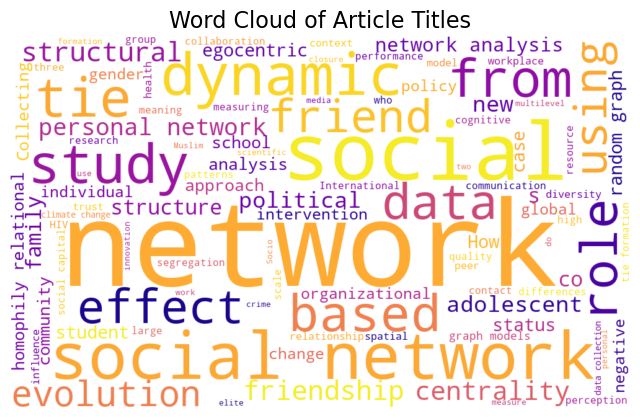

In [ ]:
# Visualize the frequency of words from title
text = "".join(research["Article"])

# Draw wordcloud
titlecloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="plasma",
    max_words=100,
    stopwords={"the", "and", "of", "to", "in", "for", "a", "an", "on", "among", "is", "with", "between", "or", "as", "across", "are"} 
).generate(text)

plt.figure(figsize=(8,6))
plt.imshow(titlecloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Article Titles", fontsize=16)
plt.show()

In [ ]:
# Compute keywords frequency
# Split keywords
keywords = (research["Keywords"]
            .dropna()
            .str.split(",")
            .explode()
            .str.strip())

keywords.value_counts()

Keywords
Social network analysis             13
Stochastic actor-oriented models     8
Social networks                      8
Homophily                            7
Personal networks                    7
                                    ..
Correlation                          1
Threshold graphs                     1
Cognitive Social Structures          1
Network motifs                       1
Exact statistics                     1
Name: count, Length: 674, dtype: int64

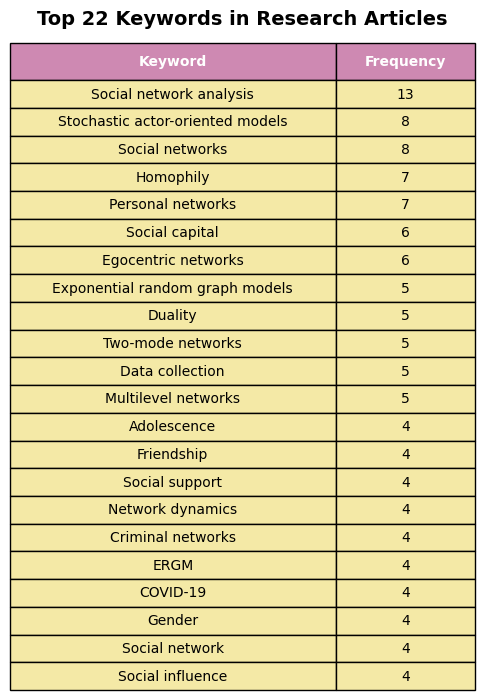

In [49]:
# Top 22 frequent keywords
top22 = keywords.value_counts().head(22).reset_index()
top22.columns = ["Keyword", "Frequency"]

# Set figure size
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

# Creat table data
table_data = [["Keyword", "Frequency"]] + top22.values.tolist()

# Draw tablee
table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    colWidths=[0.7, 0.3]
)

# Table background colors
for (row, col), cell in table.get_celld().items():
    if row == 0: 
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#CE89B2")
        cell.set_height(0.08)
    else:
        cell.set_facecolor("#F4E9A6")
        cell.set_height(0.06)

# Table title
plt.title("Top 22 Keywords in Research Articles", fontsize=14, pad=80, weight='bold')
plt.show()

In [50]:
research.head()


,Volume,Date,Article,Authors,Article_URL,Type,Keywords,page,date
0,Volume 84,In progress (January 2026),Network interventions to improve search and fa...,"Jennifer Watling Neal, Zachary P. Neal",https://www.sciencedirect.com/science/article/...,Research article,"Intervention, Research-practice gap, Research-...",In progress,2026-01
1,Volume 84,In progress (January 2026),The co-evolution of informal social status and...,"Emily Kruidhof, Rense Corten, Lea Ellwardt, Ra...",https://www.sciencedirect.com/science/article/...,Research article,"Co-evolution, Informal social status, Gossip, ...",In progress,2026-01
2,Volume 84,In progress (January 2026),Networked inequality: The role of changes in n...,"Alejandro Plaza, Guillermo Beck, Julio Iturra-...",https://www.sciencedirect.com/science/article/...,Research article,"Personal networks, Social influence, Social cl...",In progress,2026-01
3,Volume 84,In progress (January 2026),Robust network scale-up method estimators,"Sergio Díaz-Aranda, Juan Marcos Ramírez, Jose ...",https://www.sciencedirect.com/science/article/...,Research article,"Network scale-up method, Aggregated relational...",In progress,2026-01
4,Volume 84,In progress (January 2026),Can an eye for an eye turn the whole world san...,"Khrystyna Holynska, Renato Corbetta, Carter T....",https://www.sciencedirect.com/science/article/...,Research article,"International sanctions, Social network analys...",In progress,2026-01


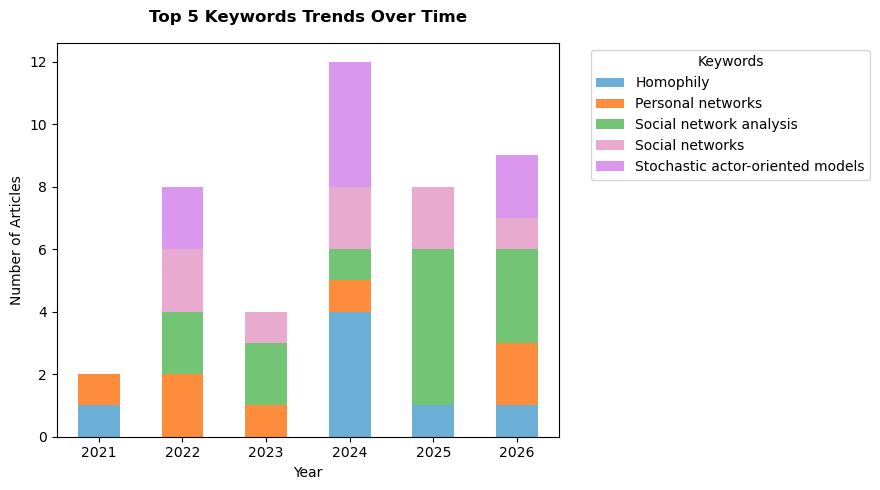

In [ ]:
# Top5 keywords
top5 = keywords.value_counts().head(5).index.tolist()

# Subset date from research
keyword_data = research.dropna(subset=["Keywords"]).copy()
keyword_data["Keywords"] = keyword_data["Keywords"].str.split(",")
keyword_data = keyword_data.explode("Keywords")
keyword_data["Keywords"] = keyword_data["Keywords"].str.strip()

#Only reserve rows with top 5 keywords
keyword5 = keyword_data[keyword_data["Keywords"].isin(top5)].copy()
keyword5["year"] = keyword5["date"].str[:4]

#frequency by year
keyword_trend = (
    keyword5.groupby(["year", "Keywords"])
    .size()
    .reset_index(name="count")
)

# Convert the data table
# Keywords as columns, years as index
pivot = keyword_trend.pivot(index="year", columns="Keywords", values="count").fillna(0)
pivot = pivot.sort_index()
pivot

# Draw stacked bar chart
pivot.plot(
    kind="bar",
    stacked=True,
    color=["#6BAED6", "#FD8D3C", "#74C476", "#E8ABCF", "#DB97EE"], 
    figsize = (9, 5)
)

plt.title("Top 5 Keywords Trends Over Time", weight="bold", pad=15)
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.legend(title="Keywords", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
